# Reproduce Section V

**Switching-Reference Voltage Control for Distribution Systems with AI-Training Data Centers**: Tables I/II + Figs 3-6.

## Setup

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the switchref/ repo root so the package is importable whether
# the notebook is launched from the repo root or this folder.
# (Skipped automatically once `pip install -e .` is run from the repo.)
HERE = Path.cwd()
ROOT = HERE if (HERE / 'switchref').is_dir() else HERE.parent
sys.path.insert(0, str(ROOT))

from switchref import (
    setup_common, setup_two_bus,
    load_h200_regulated, load_two_bus,
    action_linear, AdaRefVBiasAmpMaxDV,
    closed_loop, closed_loop_two_bus,
    compute_metrics,
    # Constants (see switchref/config.py)
    ALPHA, BETA, GAMMA, C_RATE, ETA_B,
    K_SCALE, DEADBAND, STRIDE_CTRL, DT,
    TRACES, T_CYCLE_H200,
)
from switchref.plotting import (
    plot_publication_scenario_2col,
    plot_publication_loadsmooth_sc,
    SUB_BUSES_DEFAULT,
)

FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
print('Imports OK.')

Imports OK.


## Design rule

Four constants, identical across traces:

$$\alpha = 1, \quad \beta = 1, \quad \gamma = \tfrac{1}{8}, \quad c = \tfrac{1}{4}.$$

At $\Delta t_{\mathrm{ctrl}} = 1$&nbsp;s:

$$N_a\,\Delta t_{\mathrm{ctrl}} = \alpha\,T_{\mathrm{cycle}},\quad N_b\,\Delta t_{\mathrm{ctrl}} = \beta\,T_{\mathrm{cycle}},\quad D_b\,\Delta t_{\mathrm{ctrl}} = \gamma\,T_{\mathrm{cycle}},\quad \eta_b = c\,\gamma = \tfrac{1}{32}.$$

Only $T_{\mathrm{cycle}}$ varies per trace.

### Per-trace values

In [2]:
print(f'eta_b = {ETA_B:.5f}  (same for every trace)')
print()
print(f"{'Trace':<11}{'T_cycle':>10}{'N_a':>8}{'N_b':>8}{'D_b':>8}")
for name, cyc, _ in TRACES:
    print(f"{name:<11}{cyc:>10.0f}{ALPHA*cyc:>8.1f}{BETA*cyc:>8.1f}{GAMMA*cyc:>8.2f}")

eta_b = 0.03125  (same for every trace)

Trace         T_cycle     N_a     N_b     D_b
DGX-H100           17    17.0    17.0    2.12
4xH100             97    97.0    97.0   12.12
4xL40S            107   107.0   107.0   13.38
4xA100            131   131.0   131.0   16.38
4xH200            132   132.0   132.0   16.50


## Runners

`run_fixed`: linear droop, $v^{\mathrm{ref}} = 1$ p.u. `run_switching`: AdaRefVBiasAmpMaxDV (Algorithm 1), cycle-derived $(N_a, N_b, D_b, \eta_b)$.

In [3]:
def run_fixed(ctx, ds):
    V0 = np.zeros((ctx['num_buses'], 1))
    return closed_loop(
        ctx=ctx, ds=ds,
        ctrl_step=lambda k, V: action_linear(V, ctx['K'] * K_SCALE, V0, deadband=DEADBAND),
        stride_ctrl=STRIDE_CTRL,
    )


def run_switching(ctx, ds, cycle_s):
    dt_ctrl = STRIDE_CTRL * ctx['dt_sys']      # 1 s
    N_a = max(1, int(round(ALPHA * cycle_s / dt_ctrl)))
    N_b = max(1, int(round(BETA  * cycle_s / dt_ctrl)))
    D_b = max(1, int(round(GAMMA * cycle_s / dt_ctrl)))
    ctrl = AdaRefVBiasAmpMaxDV(
        n=ctx['num_buses'], K=ctx['K'] * K_SCALE,
        action_kwargs={'deadband': DEADBAND},
        bias_len=N_b, bias_per=D_b, bias_frac=ETA_B,
        amp_win_len=N_a,
    )
    return closed_loop(ctx=ctx, ds=ds,
                       ctrl_step=lambda k, V: ctrl.step(V),
                       stride_ctrl=STRIDE_CTRL)

## Table I

Six-cycle warmup. Network-level metrics over $(i, t)$:

* `viol` $=$ RMS of $\max(|v_{i,t} - 1| - 0.05,\ 0)$.
* `eff` $=$ RMS of $\Delta q_{i,t}$.

In [4]:
table_rows = []
Vfix_store, dQfix_store = {}, {}
Vsw_store,  dQsw_store  = {}, {}

for name, cyc, loader in TRACES:
    warm = 6.0 * cyc

    ctx = setup_common(); ds = loader(ctx)
    dQf, Vf = run_fixed(ctx, ds)
    mf = compute_metrics(dQf, Vf, dt=ctx['env'].dt, warmup_secs=warm)

    ctx = setup_common(); ds = loader(ctx)
    dQs, Vs = run_switching(ctx, ds, cycle_s=cyc)
    ms = compute_metrics(dQs, Vs, dt=ctx['env'].dt, warmup_secs=warm)

    table_rows.append({
        'trace': name, 'cycle_s': cyc, 'warmup_s': warm,
        'fix_viol': mf['rms_excess']*1e4, 'fix_eff': mf['rms_dq']*1e4,
        'sw_viol':  ms['rms_excess']*1e4, 'sw_eff':  ms['rms_dq']*1e4,
    })
    Vfix_store[name], dQfix_store[name] = Vf, dQf
    Vsw_store[name],  dQsw_store[name]  = Vs, dQs

print('=' * 78)
print('Table I  (single-DC; values x1e-4 p.u.)')
print('=' * 78)
print(f"{'Trace':<12}{'Fix viol':>10}{'Sw viol':>10}{'violÃƒâ€”':>10}{'Fix eff':>10}{'Sw eff':>10}{'effÃƒâ€”':>10}")
for r in table_rows:
    vr = r['fix_viol'] / r['sw_viol'] if r['sw_viol'] > 1e-4 else float('inf')
    er = r['fix_eff']  / r['sw_eff']
    vrs = '>10^3' if vr == float('inf') or vr > 1e3 else f'{vr:.1f}x'
    print(f"{r['trace']:<12}{r['fix_viol']:>10.3f}{r['sw_viol']:>10.3f}{vrs:>10}"
          f"{r['fix_eff']:>10.3f}{r['sw_eff']:>10.3f}{er:>9.1f}x")

with open(FIG_DIR / 'table1_metrics.json', 'w') as f:
    json.dump({'design_rule': {'alpha': ALPHA, 'beta': BETA, 'gamma': GAMMA,
                               'c_rate': C_RATE, 'eta_b': ETA_B},
               'rows': table_rows}, f, indent=2)
print('\n-> figures/table1_metrics.json')

Table I  (single-DC; values x1e-4 p.u.)
Trace         Fix viol   Sw viol violÃƒâ€”   Fix eff    Sw eff  effÃƒâ€”
DGX-H100         3.420     0.245     14.0x     3.375     0.999      3.4x
4xH100           3.792     0.000     >10^3     3.155     0.184     17.1x
4xL40S           2.398     0.000     >10^3     2.978     0.233     12.8x
4xA100           3.076     0.132     23.2x     2.826     0.449      6.3x
4xH200           3.918     0.234     16.7x     3.023     0.152     19.9x

-> figures/table1_metrics.json


## Fig 3: 4&times;H200 detail

-> figures/fig3_single_dc.pdf


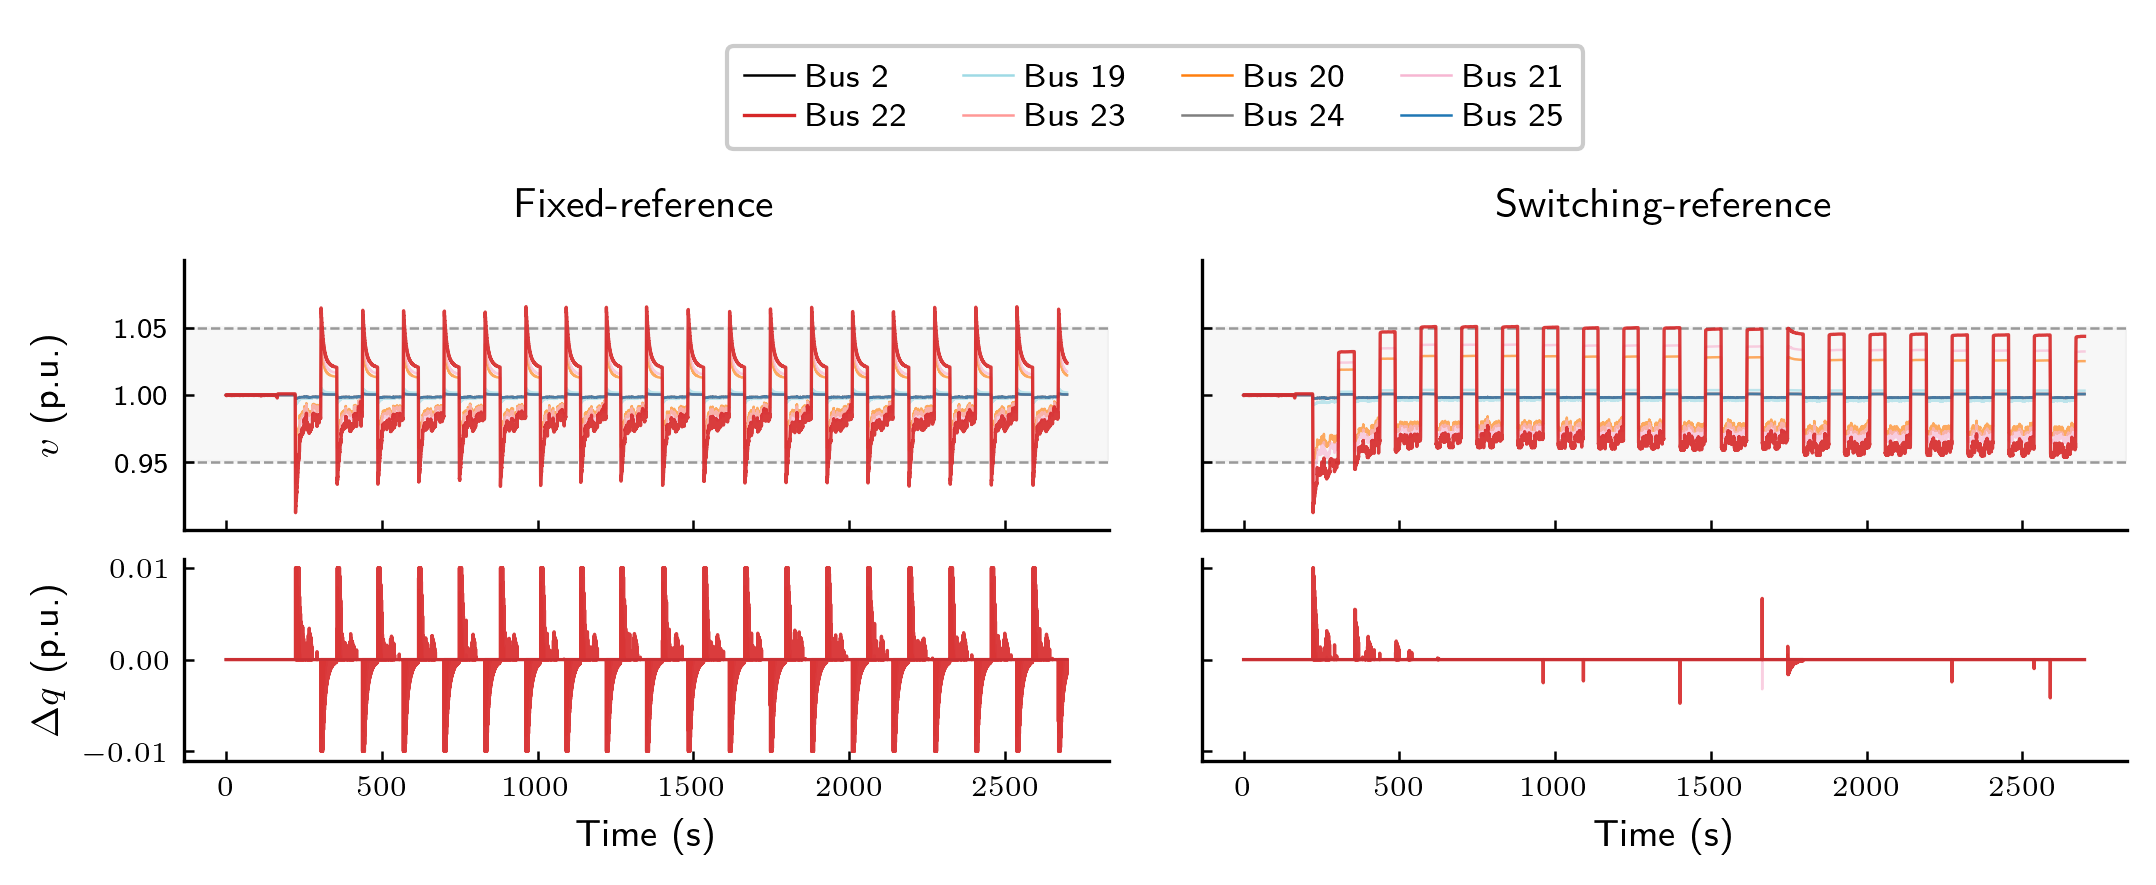

In [5]:
ctx_h200 = setup_common()
runs_h200 = [
    {'dQ': dQfix_store['4xH200'], 'V': Vfix_store['4xH200'], 'dc_buses': [ctx_h200['dc_bus']]},
    {'dQ': dQsw_store ['4xH200'], 'V': Vsw_store ['4xH200'], 'dc_buses': [ctx_h200['dc_bus']]},
]
out_fig3 = FIG_DIR / 'fig3_single_dc.pdf'
plot_publication_scenario_2col(
    runs_h200,
    bus_colors=ctx_h200['bus_colors'],
    plot_buses=SUB_BUSES_DEFAULT,
    save_path=str(out_fig3),
    dt=ctx_h200['env'].dt,
)
print('-> figures/fig3_single_dc.pdf')
plt.show()

## Fig 4: four-trace overlay

4&times;H200 / 4&times;H100 / 4&times;L40S / DGX-H100. Columns: load $L_{\mathrm{dc}}$, voltage $v$, control $\Delta q$. Per-row plot window is the 6-cycle segment with the largest fixed-reference band excursion (window endpoints are at compute-phase troughs).

-> figures/fig4_generalization.pdf


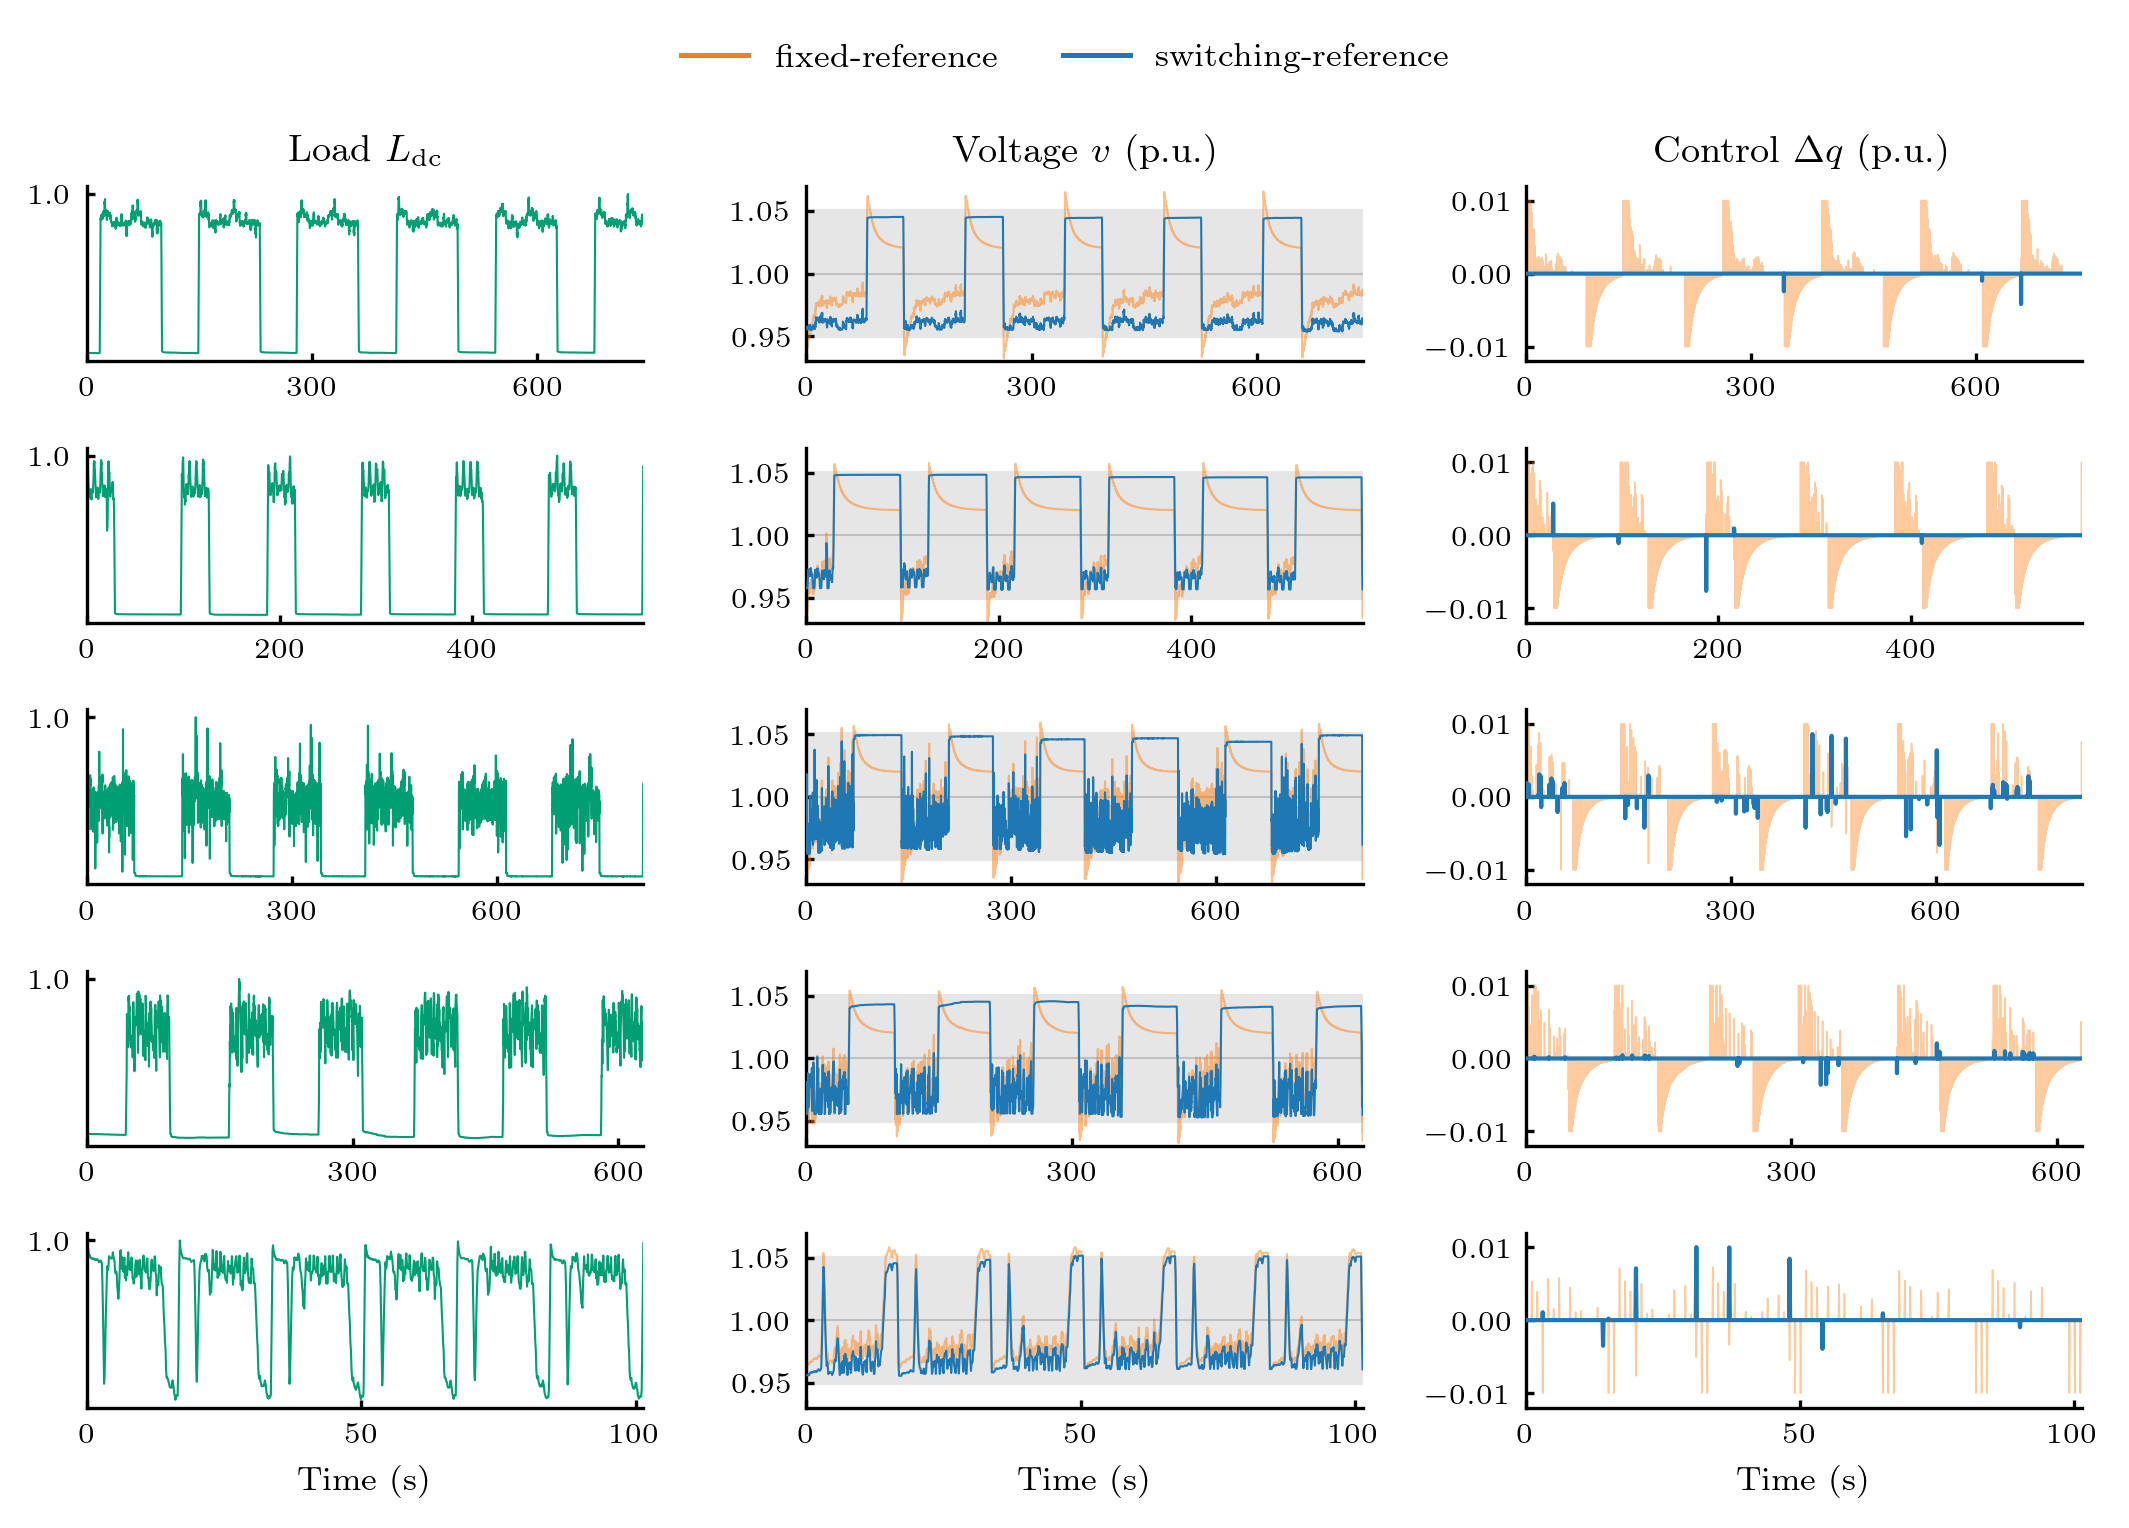

In [6]:
BUS = 20             # data-center bus (label 22)
# C_FIX = '#E69F00'    # Wong orange (colorblind-safe alternative)
# C_SW  = '#CC79A7'    # Wong reddish purple
C_FIX = '#ff7f0e'    # matplotlib tab:orange for fixed-reference
C_SW  = '#1f77b4'    # matplotlib tab:blue for switching-reference
C_PWR = '#009E73'    # Wong bluish-green for the (shared) data center load input

from scipy.signal import find_peaks

# Row order matches the paper Table I: 4xH200, 4xH100, 4xA100, 4xL40S, DGX-H100.
# t0 is the lower bound under which the worst-violation window is searched.
EXPS_FIG4 = [
    ('4xH200',   132, 1000.0),
    ('4xH100',    97,  700.0),
    ('4xA100',   131,  900.0),
    ('4xL40S',   107,  700.0),
    ('DGX-H100',  17,  150.0),
]
N_CYC = 6
loaders = {name: loader for name, cyc, loader in TRACES}


def find_worst_violation_window(Vf, bus, cyc, dt, n_cyc, t_min):
    """Window = trough[i]..trough[i+n_cyc] of the fixed-reference V at `bus`
    that minimizes integrated band excess (representative steady-state stretch where typical controller response is visible without large transient spikes dominating the view). Both endpoints sit on compute-phase
    voltage troughs, so the window spans exactly n_cyc complete cycles."""
    v_bus = Vf[:, bus] + 1.0
    violation = np.maximum(np.abs(v_bus - 1.0) - 0.05, 0.0)
    troughs, _ = find_peaks(-Vf[:, bus], distance=int(0.6 * cyc / dt))
    tV = np.arange(len(Vf)) * dt
    troughs = troughs[tV[troughs] >= t_min]
    best_i, best_score = 0, np.inf
    for i in range(len(troughs) - n_cyc):
        s = float(np.sum(violation[troughs[i]:troughs[i + n_cyc]]))
        if s < best_score:
            best_score, best_i = s, i
    return tV[troughs[best_i]], tV[troughs[best_i + n_cyc]]


def find_worst_violation_window_load(P, tP, Vf, bus, tV, dt_pwr, cyc, n_cyc, t_min):
    """DGX-H100 voltage troughs are too irregular; align to load troughs instead
    and then advance to the first high-power point for visual cleanliness."""
    v_bus = Vf[:, bus] + 1.0
    violation = np.maximum(np.abs(v_bus - 1.0) - 0.05, 0.0)
    troughs, _ = find_peaks(-P, distance=int(0.6 * cyc / dt_pwr))
    troughs = troughs[tP[troughs] >= t_min]
    hi = np.percentile(P, 5) + 0.8 * (np.percentile(P, 95) - np.percentile(P, 5))
    best_i, best_score = 0, np.inf
    for i in range(len(troughs) - n_cyc):
        iA, iB = troughs[i], troughs[i + n_cyc]
        while iA < len(P) - 1 and P[iA] < hi: iA += 1
        while iB < len(P) - 1 and P[iB] < hi: iB += 1
        mask = (tV >= tP[iA]) & (tV <= tP[iB])
        if not mask.any():
            continue
        s = float(np.sum(violation[mask]))
        if s < best_score:
            best_score, best_i = s, i
    iA, iB = troughs[best_i], troughs[best_i + n_cyc]
    while iA < len(P) - 1 and P[iA] < hi: iA += 1
    while iB < len(P) - 1 and P[iB] < hi: iB += 1
    return tP[iA], tP[iB]


plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{bm}',
    'font.family': 'serif',
})

fig, axes = plt.subplots(len(EXPS_FIG4), 3, figsize=(7.2, 1.0 * len(EXPS_FIG4)), dpi=300)
for r, (name, cyc, t0) in enumerate(EXPS_FIG4):
    Vf, dQf = Vfix_store[name], dQfix_store[name]
    Vs, dQs = Vsw_store [name], dQsw_store [name]
    ds = loaders[name](setup_common())
    tV = np.arange(len(Vs)) * DT
    tq = np.arange(len(dQs)) * DT
    tP = ds['t_pwr']
    P = -np.asarray(ds['pwr_pwr'])

    if name == 'DGX-H100':
        dt_pwr = float(tP[1] - tP[0])
        tA, tB = find_worst_violation_window_load(P, tP, Vf, BUS, tV, dt_pwr, cyc, N_CYC, t0)
    else:
        tA, tB = find_worst_violation_window(Vf, BUS, cyc, DT, N_CYC, t0)

    mV = (tV >= tA) & (tV <= tB)
    mq = (tq >= tA) & (tq <= tB)
    mP = (tP >= tA) & (tP <= tB)

    axP, axV, axQ = axes[r, 0], axes[r, 1], axes[r, 2]

    Pw = P[mP]
    Pw = (Pw - Pw.min()) / (Pw.max() - Pw.min() + 1e-12)
    axP.plot(tP[mP] - tA, Pw, color=C_PWR, lw=0.5)
    axP.set_ylim(-0.05, 1.05)
    axP.set_yticks([1]); axP.set_yticklabels(['1.0'])

    axV.axhspan(0.95, 1.05, color='0.90', zorder=0)
    axV.axhline(1.0, color='0.75', lw=0.5, zorder=1)
    axV.plot(tV[mV] - tA, Vf[mV, BUS] + 1.0, color=C_FIX, lw=0.5, alpha=0.5, zorder=2)
    axV.plot(tV[mV] - tA, Vs[mV, BUS] + 1.0, color=C_SW,  lw=0.5, zorder=4)
    axV.set_ylim(0.93, 1.07); axV.set_yticks([0.95, 1.0, 1.05])

    axQ.axhline(0.0, color='0.75', lw=0.5)
    # Fixed-ref Delta q has tall spikes; draw it semi-transparent so the
    # smaller switching-ref response on top remains visible.
    axQ.plot(tq[mq] - tA, dQf[mq, BUS], color=C_FIX, lw=0.4, alpha=0.4, zorder=2)
    axQ.plot(tq[mq] - tA, dQs[mq, BUS], color=C_SW,  lw=1.0, zorder=4)
    axQ.set_ylim(-0.012, 0.012); axQ.set_yticks([-0.01, 0.0, 0.01])

    if r == 0:
        axP.set_title(r'Load $L_{\mathrm{dc}}$', fontsize=9)
        axV.set_title(r'Voltage $v$ (p.u.)', fontsize=9)
        axQ.set_title(r'Control $\Delta q$ (p.u.)', fontsize=9)

    _half = (tB - tA) / 2
    _mag = 10.0 ** np.floor(np.log10(_half))
    _step = next(m * _mag for m in (5, 3, 2, 1) if m * _mag <= _half + 1e-9)
    xticks = [0, _step, 2 * _step]
    for ax in (axP, axV, axQ):
        ax.set_xlim(0, tB - tA)
        ax.tick_params(labelsize=7, direction='in', length=2.0)
        ax.set_xticks(xticks)
        ax.spines[['top', 'right']].set_visible(False)
        if r == len(EXPS_FIG4) - 1:
            ax.set_xlabel('Time (s)', fontsize=8)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=C_FIX, lw=1.2),
           Line2D([0], [0], color=C_SW,  lw=1.2)]
fig.legend(handles, ['fixed-reference', 'switching-reference'],
           loc='upper center', ncol=2, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.97])

out_fig4 = FIG_DIR / 'fig4_generalization.pdf'
fig.savefig(out_fig4, format='pdf', bbox_inches='tight', pad_inches=0.02)
print('-> figures/fig4_generalization.pdf')
plt.show()

Log-log slopes:
  viol_fix : -0.023
  eff_fix  : -0.066
  viol_sw  : -0.161
  eff_sw   : -0.720


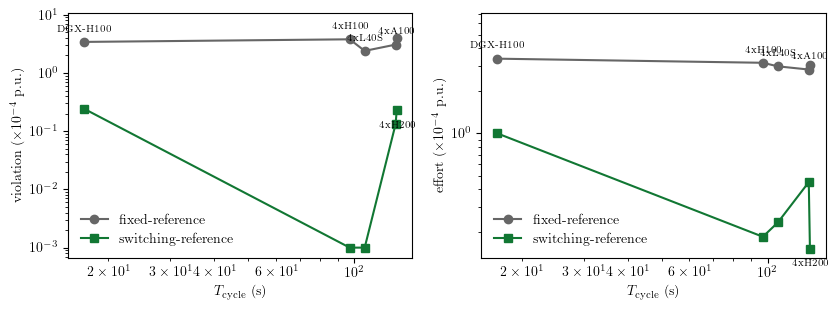

In [7]:
Ts = np.array([r['cycle_s'] for r in table_rows], dtype=float)
viol_fix = np.array([r['fix_viol'] for r in table_rows])
viol_sw  = np.array([r['sw_viol']  for r in table_rows])
eff_fix  = np.array([r['fix_eff']  for r in table_rows])
eff_sw   = np.array([r['sw_eff']   for r in table_rows])

def loglog_slope(T, y):
    mask = y > 1e-6
    if mask.sum() < 2:
        return float('nan')
    slope, _ = np.polyfit(np.log(T[mask]), np.log(y[mask]), 1)
    return slope

print('Log-log slopes:')
print(f"  viol_fix : {loglog_slope(Ts, viol_fix):+.3f}")
print(f"  eff_fix  : {loglog_slope(Ts, eff_fix):+.3f}")
print(f"  viol_sw  : {loglog_slope(Ts, viol_sw):+.3f}")
print(f"  eff_sw   : {loglog_slope(Ts, eff_sw):+.3f}")

trace_names = [r['trace'] for r in table_rows]
LABEL_BELOW = {'4xH200'}
C_SW_PLOT = '#117733'

fig2, ax = plt.subplots(1, 2, figsize=(8.5, 3.2))
for axi, ylab, yf, ys in [(ax[0], r'violation ($\times 10^{-4}$ p.u.)', viol_fix, viol_sw),
                          (ax[1], r'effort ($\times 10^{-4}$ p.u.)',    eff_fix,  eff_sw)]:
    axi.loglog(Ts, yf, 'o-', color='0.4',     label='fixed-reference')
    axi.loglog(Ts, np.maximum(ys, 1e-3), 's-', color=C_SW_PLOT, label='switching-reference')
    axi.set_xlabel(r'$T_{\mathrm{cycle}}$ (s)')
    axi.set_ylabel(ylab)
    axi.legend(frameon=False, loc='lower left')
    for x, t, yh, yl in zip(Ts, trace_names, yf, np.maximum(ys, 1e-3)):
        if t in LABEL_BELOW:
            axi.annotate(t, (x, yl), xytext=(0, -8), textcoords='offset points',
                         fontsize=7, ha='center', va='top')
        else:
            axi.annotate(t, (x, yh), xytext=(0, 6), textcoords='offset points',
                         fontsize=7, ha='center', va='bottom')
    y0, y1 = axi.get_ylim()
    axi.set_ylim(y0, y1 * 1.8)
fig2.tight_layout()
plt.show()

## Two-DC (&sect;V-B.1)

H200 `b16x2` at bus 22, `b8x2` at bus 25. $T_{\mathrm{cycle}} = 132$ s.

Table II  (two-DC; values x1e-4 p.u.)
Controller                  viol       eff
Fixed-reference            6.473     4.807
Switching-reference        0.877     0.252
Improvement                 7.4x     19.1x



-> figures/fig5_two_dc.pdf


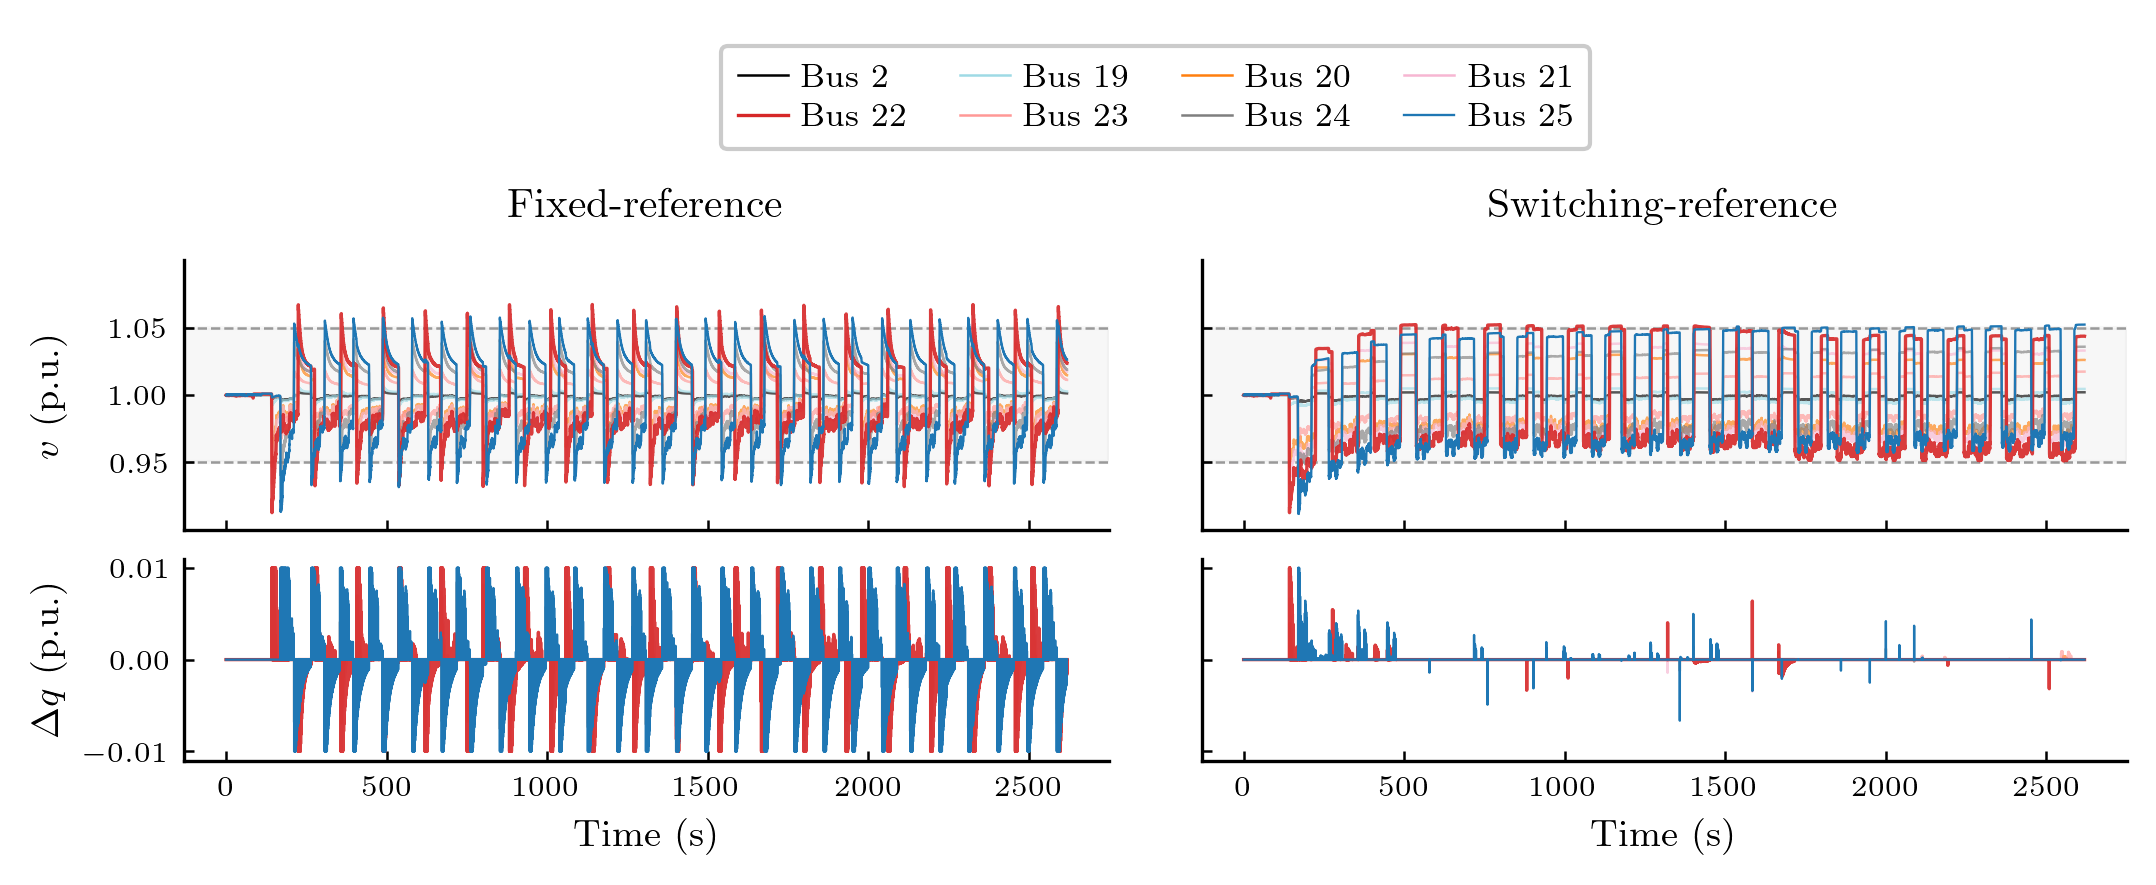

In [8]:
WARMUP_2DC = 6.0 * T_CYCLE_H200

def run_two_dc_fixed(ctx2, ds2):
    V0 = np.zeros((ctx2['num_buses'], 1))
    return closed_loop_two_bus(
        ctx=ctx2, ds=ds2,
        ctrl_step=lambda k, V: action_linear(V, ctx2['K'] * K_SCALE, V0, deadband=DEADBAND),
        stride_ctrl=STRIDE_CTRL,
    )

def run_two_dc_switching(ctx2, ds2, cycle_s):
    dt_ctrl = STRIDE_CTRL * ctx2['dt_sys']
    N_a = max(1, int(round(ALPHA * cycle_s / dt_ctrl)))
    N_b = max(1, int(round(BETA  * cycle_s / dt_ctrl)))
    D_b = max(1, int(round(GAMMA * cycle_s / dt_ctrl)))
    ctx2['env'].reset(P=ctx2['P0_INIT'], balance_Q=True)
    ctrl = AdaRefVBiasAmpMaxDV(
        n=ctx2['num_buses'], K=ctx2['K'] * K_SCALE,
        action_kwargs={'deadband': DEADBAND},
        bias_len=N_b, bias_per=D_b, bias_frac=ETA_B,
        amp_win_len=N_a,
    )
    return closed_loop_two_bus(
        ctx=ctx2, ds=ds2,
        ctrl_step=lambda k, V: ctrl.step(V),
        stride_ctrl=STRIDE_CTRL,
        vref_getter=lambda: ctrl.V_ref,
    )

ctx2 = setup_two_bus(); ds2 = load_two_bus(ctx2)
res_fix = run_two_dc_fixed(ctx2, ds2)
ctx2 = setup_two_bus(); ds2 = load_two_bus(ctx2)
res_sw  = run_two_dc_switching(ctx2, ds2, cycle_s=T_CYCLE_H200)

m_fix = compute_metrics(res_fix['record_dQ'], res_fix['record_V'],
                        dt=ctx2['env'].dt, warmup_secs=WARMUP_2DC)
m_sw  = compute_metrics(res_sw['record_dQ'],  res_sw['record_V'],
                        dt=ctx2['env'].dt, warmup_secs=WARMUP_2DC)

print('=' * 70)
print('Table II  (two-DC; values x1e-4 p.u.)')
print('=' * 70)
print(f"{'Controller':<22}{'viol':>10}{'eff':>10}")
print(f"{'Fixed-reference':<22}{m_fix['rms_excess']*1e4:>10.3f}{m_fix['rms_dq']*1e4:>10.3f}")
print(f"{'Switching-reference':<22}{m_sw['rms_excess']*1e4:>10.3f}{m_sw['rms_dq']*1e4:>10.3f}")
vr = m_fix['rms_excess'] / m_sw['rms_excess'] if m_sw['rms_excess'] > 1e-8 else float('inf')
er = m_fix['rms_dq'] / m_sw['rms_dq']
print(f"{'Improvement':<22}{vr:>9.1f}x{er:>9.1f}x")

# Fig 5 (two-DC time-domain)
runs_2dc = [
    {'dQ': res_fix['record_dQ'], 'V': res_fix['record_V'], 'dc_buses': ctx2['dc_buses']},
    {'dQ': res_sw['record_dQ'],  'V': res_sw['record_V'],  'dc_buses': ctx2['dc_buses']},
]
out_fig5 = FIG_DIR / 'fig5_two_dc.pdf'
plot_publication_scenario_2col(
    runs_2dc,
    bus_colors=ctx2['bus_colors'],
    plot_buses=SUB_BUSES_DEFAULT,
    save_path=str(out_fig5),
    dt=ctx2['env'].dt,
)
print('\n-> figures/fig5_two_dc.pdf')
plt.show()

## Fig 6: load smoothing (&sect;V-B.2)

4&times;H200 head + storage-regulated tail. Switching-ref adapts across the regime change without retuning.

Exp 3 (switching-ref on regulated tail):
  rms_excess = 0.321e-4
  rms_dq     = 0.308e-4
  violation_rate = 6.88%


-> figures/fig6_load_smoothing.pdf


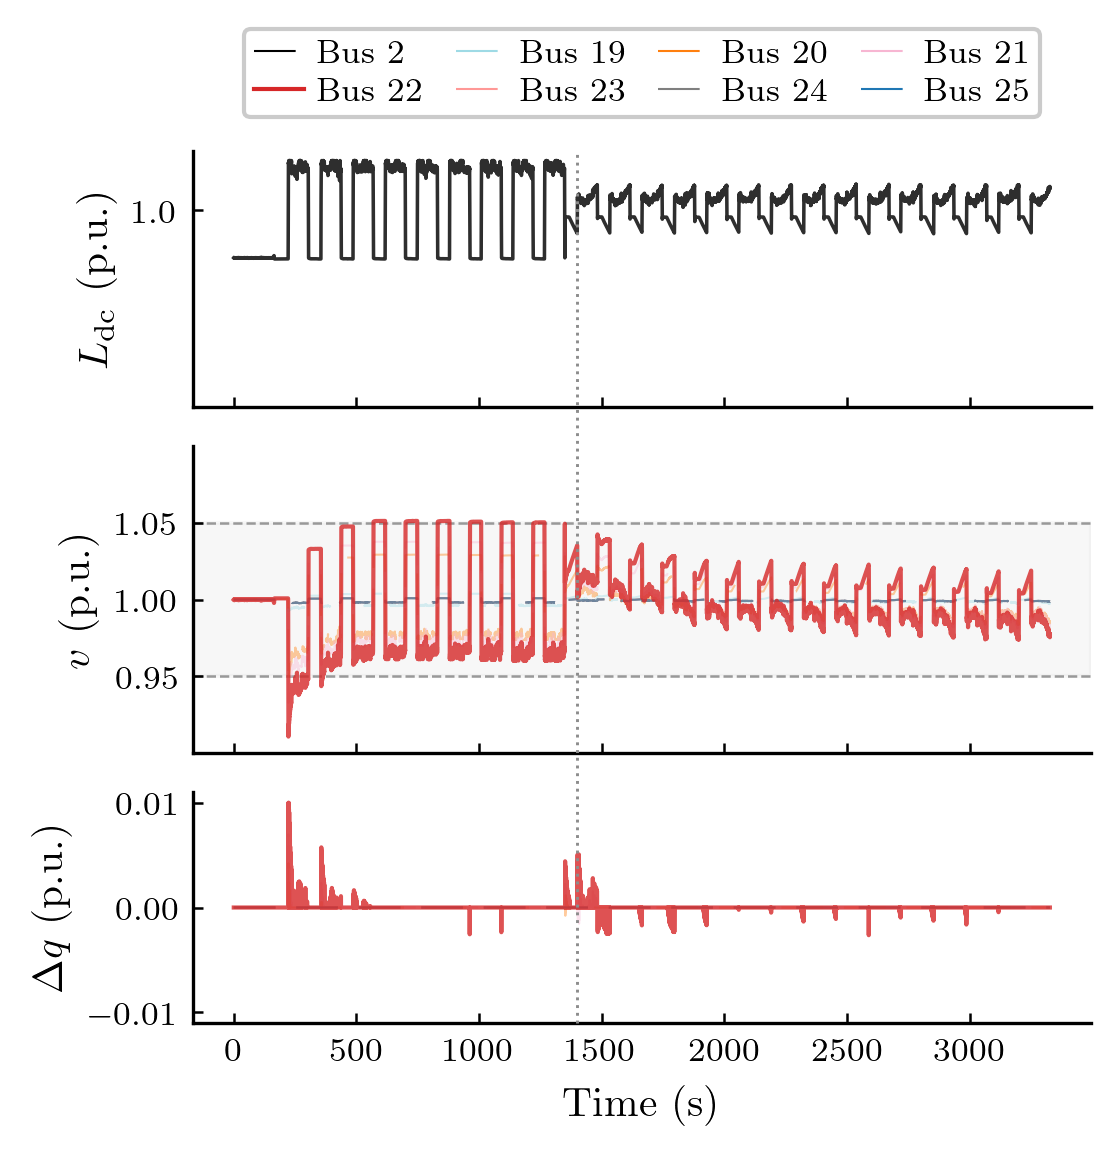

In [9]:
ctx = setup_common(); ds = load_h200_regulated(ctx)
warm = 6.0 * T_CYCLE_H200

dt_ctrl = STRIDE_CTRL * ctx['dt_sys']
N_a = max(1, int(round(ALPHA * T_CYCLE_H200 / dt_ctrl)))
N_b = max(1, int(round(BETA  * T_CYCLE_H200 / dt_ctrl)))
D_b = max(1, int(round(GAMMA * T_CYCLE_H200 / dt_ctrl)))
ctrl = AdaRefVBiasAmpMaxDV(
    n=ctx['num_buses'], K=ctx['K'] * K_SCALE,
    action_kwargs={'deadband': DEADBAND},
    bias_len=N_b, bias_per=D_b, bias_frac=ETA_B,
    amp_win_len=N_a,
)
dQ_e, V_e = closed_loop(ctx=ctx, ds=ds,
                        ctrl_step=lambda k, V: ctrl.step(V),
                        stride_ctrl=STRIDE_CTRL)
m_e = compute_metrics(dQ_e, V_e, dt=ctx['env'].dt, warmup_secs=warm)
print('Exp 3 (switching-ref on regulated tail):')
print(f"  rms_excess = {m_e['rms_excess']*1e4:.3f}e-4")
print(f"  rms_dq     = {m_e['rms_dq']*1e4:.3f}e-4")
print(f"  violation_rate = {m_e['violation_rate']*100:.2f}%")

# Sign-flip ds['pwr_pwr'] (negative-by-convention in the loader) and
# center it near 1.0 p.u. so the L_dc panel reads as a normalized load trace.
_t = ds['t_pwr']
_p = -np.asarray(ds['pwr_pwr'])
_p = _p + (1.0 - float(np.median(_p))) + 0.05

out_fig6 = FIG_DIR / 'fig6_load_smoothing.pdf'
plot_publication_loadsmooth_sc(
    _t, _p, dQ_e, V_e,
    bus_colors=ctx['bus_colors'],
    plot_buses=SUB_BUSES_DEFAULT,
    dc_buses=[ctx['dc_bus']],
    save_path=str(out_fig6),
    dt=ctx['env'].dt,
    smoothing_onset=1400.0,
)
print('-> figures/fig6_load_smoothing.pdf')
plt.show()